In [41]:
import glob
import matplotlib
from sklearn import linear_model
from scipy.signal import hilbert
from scipy import signal
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score

import pickle

def calculate_log_likelihood(y_true, y_pred_proba):
    """
    Calculates the log-likelihood for logistic regression.

    Args:
        y_true (array-like): True labels (0 or 1).
        y_pred_proba (array-like): Predicted probabilities of the positive class.

    Returns:
        float: The log-likelihood value.
    """
    # Ensure probabilities are not exactly 0 or 1 to avoid log(0) issues
    y_pred_proba = np.clip(y_pred_proba, 1e-10, 1 - 1e-10)

    log_likelihood = np.sum(y_true * np.log(y_pred_proba) + (1 - y_true) * np.log(1 - y_pred_proba))
    return log_likelihood

file_path = 'B:\HsinYi\GitHub\sensory_beh/fly_kmeanlabels.pkl'
with open(file_path, 'rb') as f:
    fly_kmeanlabels = pickle.load(f)

roll_time = 5  #rolling time for probility estimation of the outcome
states_label=[0,1]
v_smooth_window=2
lp_f = 25
accuracy_list=[]
accuracy_list2=[]
accuracy_list4=[]
states_linear_output=[]
states_linear_output2=[]
states_linear_output4=[]
fig = plt.figure()
sta_all=[]
sta_vx_all=[]
sta_all_x=[]
sta_all_y=[]
window = 50
shuffled_indicies = np.random.permutation(42991-(window-10)*16)
train_data_size = int((42991-(window-10)*16) * 3 / 4)

n_features = 1
joint=2

for stimulus_window in range(window,window+1,2):
    print(stimulus_window)
    prob_states_mul_lr=[]
    prob_states_lr = []
    prob_states_lr_2 = []
    prob_states_lr_4=[]


    for states in states_label:
        #initial_time = [569, 276, 99,184,1776,567,2435,226,1017]
        initial_time = [569, 276, 99,1776,  567, 2435,  141, 109, 204, 400, 377, 206, 170,177, 207, 169]

        videodirectory = 'B:/HsinYi/GitHub/sensory_beh/'
        videoname = '*'
        sensory_dic = videodirectory+'sensory_auto/'
        sensory_roi_files = glob.glob(sensory_dic+ videoname+ '_roi_coordinates_side.npz')
        sensory_stft_files = glob.glob(sensory_dic+ videoname+ '_roi_stft_side.npz')

        spider_labeled_beh = []
        fly_kmeanlabel_beh=[]
        observations = []
        stimulus =[]
        stimulus_all=[]
        stimulus_y = []
        stimulus_r=[]
        stimulus_all_r=[]
        stimulus_all_y = []
        stimulus_v_x = []
        stimulus_v_y = []
        stimulus_v_x_all = []
        stimulus_v_y_all = []

        observations_fly = []
        for j in range(len(sensory_roi_files)):
            sensory_roi = np.load(sensory_roi_files[j])
            roi_fly_list = sensory_roi['roi_fly_list']
            roi_spider_list = sensory_roi['roi_spider_list']
            nframes = roi_fly_list.shape[0]
            vid_name = sensory_roi_files[j].split('/sensory_auto\\')[1].split('_roi_coordinates_side.npz')[0]
            x = roi_spider_list[:, 0] + roi_spider_list[:, 2] / 2
            v_x = x - np.roll(x, 1)
            v_x = v_x[1:len(v_x)]
            y = roi_spider_list[:, 1] + roi_spider_list[:, 3] / 2
            v_y = y - np.roll(y, 1)
            v_y = v_y[1:len(v_y)]
            v_x = hilbert(v_x)
            v_x = np.abs(v_x)
            v_y = hilbert(v_y)
            v_y = np.abs(v_y)
            r = roi_spider_list[:, 1] + roi_spider_list[:, 3] / 2 - roi_fly_list[:, 1] - roi_fly_list[:, 3] / 2
            r = np.abs(r)
            r = r / ((roi_spider_list[:, 2] + roi_spider_list[:, 3])) / 2
            # r = r / np.min(r)
            r = (1 / r) ** 2
            r = r / np.max(r)
            r[np.where(r < 0.5)[0]] = 0.5

            vid_name = sensory_roi_files[j].split('/sensory_auto\\')[1].split('_roi_coordinates_side.npz')[0]

            ## Spider's beh
            beh_hmm = np.load(
                glob.glob(videodirectory + 'sensory_auto/' + vid_name + '*_hmm_umap_filtered_predictedlabels.npy')[0]
                )

            wavelet =  np.load(
                glob.glob(videodirectory + 'sensory_auto/' + vid_name + '*_nonormalized_wavelet.npz')[0]
                )
            wavelet_x = wavelet['arr_0']
            wavelet_y = wavelet['arr_1']
            ff = wavelet['arr_2']
            ## Sensory
            wavelet_x = wavelet_x[0:len(beh_hmm), :]  ## ignore wrapping time
            wavelet_x = wavelet_x.reshape(wavelet_x.shape[0], 5, 50)
            wavelet_x = np.mean(wavelet_x[:, :, 25:46], axis=1)
            wavelet_x = wavelet_x.reshape(wavelet_x.shape[0], 21)
            wavelet_x = np.mean(wavelet_x, axis=1)

            # wavelet_y = wavelet_y[0:len(beh_hmm), :]  ## ignore wrapping time
            # wavelet_y = wavelet_y.reshape(wavelet_x.shape[0], 5, 50)
            # wavelet_y = wavelet_y[:, joint, 25:46]
            # wavelet_y = wavelet_y.reshape(wavelet_y.shape[0], 21)
            # wavelet_y = np.mean(wavelet_y, axis=1)
            # wavelet_y = beh_hmm

            #wavelet_x = (wavelet_x - np.mean(wavelet_x)) / np.std(wavelet_x)




            t3 = [i for i in range(0, initial_time[j], 1)]
            t3 = np.array(t3)
            yinterp3 =wavelet_x[0:initial_time[j]]
            yinterp3_mean = np.mean(yinterp3)
            yinterp3_std = np.std(yinterp3)
            # yinterp3_y = wavelet_y[0:initial_time[j]]
            # yinterp3_mean_y = np.mean(yinterp3_y)
            # yinterp3_std_y = np.std(yinterp3_y)

            t2 = [i for i in range(initial_time[j], (len(beh_hmm) + initial_time[j]), 1)]
            # # t= [i for i in range(4000, 6000, 10)]
            t2 = np.array(t2)
            #
            yinterp = np.copy(wavelet_x)
            yinterp = (yinterp - yinterp3_mean) / yinterp3_std
            # yinterp_y = np.copy(wavelet_y)
            # yinterp_y = (yinterp_y - yinterp3_mean_y) / yinterp3_std_y

            yinterp_y = np.copy(beh_hmm)
            r = r[t2][0:len(r[t2])]
            sos = signal.butter(10, lp_f, 'lp', fs=100, output='sos')
            r = signal.sosfilt(sos, r)
            r = (r - np.mean(r)) / np.std(r)
            v_x_sensory = v_x[t2][0:len(v_x[t2])]
            v_y_sensory = v_y[t2][0:len(v_y[t2])]

            sos = signal.butter(10, lp_f, 'lp', fs=100, output='sos')
            v_x_sensory = signal.sosfilt(sos, v_x_sensory)
            v_y_sensory = signal.sosfilt(sos, v_y_sensory)

            v_x_sensory = (v_x_sensory - np.mean(v_x_sensory)) / np.std(v_x_sensory)
            v_y_sensory = (v_y_sensory - np.mean(v_y_sensory)) / np.std(v_y_sensory)

            ## Spike trigger average
            from itertools import groupby
            count_dups = [sum(1 for _ in group) for _, group in groupby(fly_kmeanlabels[j])]
            cumsum = np.cumsum(count_dups)

            groups = []
            uniquekeys = []
            for k, g in groupby(fly_kmeanlabels[j]):
                groups.append(list(g))  # Store group iterator as a list
                uniquekeys.append(k)

            idx = np.where(np.array(uniquekeys)==states)
            stimulus_temp=[]
            stimulus_temp_y=[]
            stimulus_r_temp = []
            stimulus_v_x_temp = []
            stimulus_v_y_temp = []


            for trigger in range(len(idx[0])):
                if idx[0][trigger]==0:
                    continue
                else:
                    event_time = cumsum[idx[0][trigger]-1]
                    if len(yinterp[event_time - stimulus_window:event_time])==0:
                        stimulus.append(yinterp[0:stimulus_window])
                        stimulus_temp.append(yinterp[0:stimulus_window])
                        stimulus_y.append(yinterp_y[0:stimulus_window])
                        stimulus_temp_y.append(yinterp_y[0:stimulus_window])
                        stimulus_r.append(r[0:stimulus_window])
                        stimulus_r_temp.append(r[0:stimulus_window])
                        stimulus_v_x.append(v_x_sensory[0:stimulus_window])
                        stimulus_v_y.append(v_y_sensory[0:stimulus_window])
                        stimulus_v_x_temp.append(v_x_sensory[0:stimulus_window])
                        stimulus_v_y_temp.append(v_y_sensory[0:stimulus_window])

                    else:
                        stimulus.append(yinterp[event_time - stimulus_window:event_time])
                        stimulus_temp.append(yinterp[event_time - stimulus_window:event_time])
                        stimulus_y.append(yinterp_y[event_time - stimulus_window:event_time])
                        stimulus_temp_y.append(yinterp_y[event_time - stimulus_window:event_time])
                        stimulus_r.append(r[event_time - stimulus_window:event_time])
                        stimulus_r_temp.append(r[event_time - stimulus_window:event_time])
                        stimulus_v_x.append(v_x_sensory[event_time - stimulus_window:event_time])
                        stimulus_v_y.append(v_y_sensory[event_time - stimulus_window:event_time])
                        stimulus_v_x_temp.append(v_x_sensory[event_time - stimulus_window:event_time])
                        stimulus_v_y_temp.append(v_y_sensory[event_time - stimulus_window:event_time])

            stimulus_all.append(stimulus_temp)
            stimulus_all_y.append(stimulus_temp_y)
            stimulus_all_r.append(stimulus_r_temp)
            stimulus_v_x_all.append(stimulus_v_x_temp)
            stimulus_v_y_all.append(stimulus_v_y_temp)


            fly_kmeanlabel_beh.append(fly_kmeanlabels[j])
            spider_labeled_beh.append(beh_hmm[stimulus_window:len(beh_hmm)])
            observations.append(list(yinterp))



        ## Spike trigger average of all videos. Mean centered
        stimulus_test = np.array(stimulus)
        data_ensembles_len = stimulus_test.shape[0]
        arr = np.arange(data_ensembles_len)
        np.random.shuffle(arr)
        #train_set = stimulus_test[arr[0:int(len(arr)*3/4)]]
        #test_set = stimulus_test[arr[int(len(arr)*3/4):len(arr)]]
        train_set = stimulus_test
        sta = np.mean(train_set, axis=0)
 
        sta_all.append(sta)


        stimulus_test = np.array(stimulus_v_x)
        data_ensembles_len = stimulus_test.shape[0]
        arr = np.arange(data_ensembles_len)
        np.random.shuffle(arr)
        # train_set = stimulus_test[arr[0:int(len(arr)*3/4)]]
        # test_set = stimulus_test[arr[int(len(arr)*3/4):len(arr)]]
        train_set = stimulus_test
        sta_x = np.mean(train_set, axis=0)
 
        sta_all_x.append(sta_x)


        stimulus_test = np.array(stimulus_v_y)
        data_ensembles_len = stimulus_test.shape[0]
        arr = np.arange(data_ensembles_len)
        np.random.shuffle(arr)
        # train_set = stimulus_test[arr[0:int(len(arr)*3/4)]]
        # test_set = stimulus_test[arr[int(len(arr)*3/4):len(arr)]]
        train_set = stimulus_test
        sta_y = np.mean(train_set, axis=0)

        sta_all_y.append(sta_y)




        ### Step 2: Linear Output

        labeled_beh = []
        observations = []
        observations_fly = []

        linear_output_all=[]
        linear_output_all_y=[]
        linear_output_all_x=[]

        for j in range(len(sensory_roi_files)):
            sensory_roi = np.load(sensory_roi_files[j])
            roi_fly_list = sensory_roi['roi_fly_list']
            roi_spider_list = sensory_roi['roi_spider_list']
            nframes = roi_fly_list.shape[0]
            vid_name = sensory_roi_files[j].split('/sensory_auto\\')[1].split('_roi_coordinates_side.npz')[0]
            x = roi_spider_list[:, 0] + roi_spider_list[:, 2] / 2
            v_x = x - np.roll(x, 1)
            v_x = v_x[1:len(v_x)]
            y = roi_spider_list[:, 1] + roi_spider_list[:, 3] / 2
            v_y = y - np.roll(y, 1)
            v_y = v_y[1:len(v_y)]
            v_x = hilbert(v_x)
            v_x = np.abs(v_x)
            v_y = hilbert(v_y)
            v_y = np.abs(v_y)
            sensory_roi = np.load(sensory_roi_files[j])
            roi_fly_list = sensory_roi['roi_fly_list']
            roi_spider_list = sensory_roi['roi_spider_list']
            nframes = roi_fly_list.shape[0]
            vid_name = sensory_roi_files[j].split('/sensory_auto\\')[1].split('_roi_coordinates_side.npz')[0]
            r = roi_spider_list[:, 1] + roi_spider_list[:, 3] / 2 - roi_fly_list[:, 1] - roi_fly_list[:, 3] / 2
            r = np.abs(r)
            r = r / ((roi_spider_list[:, 2] + roi_spider_list[:, 3])) / 2
            # r = r / np.min(r)
            r = (1 / r) ** 2
            r = r / np.max(r)
            r[np.where(r < 0.5)[0]] = 0.5

            vid_name = sensory_roi_files[j].split('/sensory_auto\\')[1].split('_roi_coordinates_side.npz')[0]

            ## Spider's beh
            beh_hmm = np.load(
                glob.glob(videodirectory + 'sensory_auto/' + vid_name + '*_hmm_umap_filtered_predictedlabels.npy')[0]
            )

            wavelet = np.load(
                glob.glob(videodirectory + 'sensory_auto/' + vid_name + '*_nonormalized_wavelet.npz')[0]
            )
            wavelet_x = wavelet['arr_0']
            wavelet_y = wavelet['arr_1']
            ff = wavelet['arr_2']
            ## Sensory
            wavelet_x = wavelet_x[0:len(beh_hmm), :]  ## ignore wrapping time
            wavelet_x = wavelet_x.reshape(wavelet_x.shape[0], 5, 50)
            wavelet_x = np.mean(wavelet_x[:, :, 25:46], axis=1)
            wavelet_x = wavelet_x.reshape(wavelet_x.shape[0], 21)
            wavelet_x = np.mean(wavelet_x, axis=1)


            yinterp3 = wavelet_x[0:initial_time[j]]
            yinterp3_mean = np.mean(yinterp3)
            yinterp3_std = np.std(yinterp3)
            # yinterp3_y = wavelet_y[0:initial_time[j]]
            # yinterp3_mean_y = np.mean(yinterp3_y)
            # yinterp3_std_y = np.std(yinterp3_y)

            t2 = [i for i in range(initial_time[j], (len(beh_hmm) + initial_time[j]), 1)]
            # # t= [i for i in range(4000, 6000, 10)]
            t2 = np.array(t2)
            #
            yinterp = np.copy(wavelet_x)
            yinterp = (yinterp - yinterp3_mean) / yinterp3_std
            # yinterp_y = np.copy(wavelet_y)
            # yinterp_y = (yinterp_y - yinterp3_mean_y) / yinterp3_std_y

            yinterp_y = np.copy(beh_hmm)

            r = r[t2][0:len(r[t2])]
            sos = signal.butter(10, lp_f, 'lp', fs=100, output='sos')
            r = signal.sosfilt(sos, r)
            r = (r - np.mean(r)) / np.std(r)
            v_x_sensory = v_x[t2][0:len(v_x[t2])]
            v_y_sensory = v_y[t2][0:len(v_y[t2])]

            sos = signal.butter(10, lp_f, 'lp', fs=100, output='sos')
            v_x_sensory = signal.sosfilt(sos, v_x_sensory)
            v_y_sensory = signal.sosfilt(sos, v_y_sensory)

            v_x_sensory = (v_x_sensory - np.mean(v_x_sensory)) / np.std(v_x_sensory)
            v_y_sensory = (v_y_sensory - np.mean(v_y_sensory)) / np.std(v_y_sensory)


            X_windows = np.array([yinterp[t - window:t] for t in range(window, yinterp.shape[0])])
            X_flat = X_windows.reshape((yinterp.shape[0] - window, window * n_features))
            linear_output = X_flat @ sta.reshape(-1)

            Y_windows = np.array([v_x_sensory [t - window:t] for t in range(window, v_x_sensory .shape[0])])
            Y_flat = Y_windows.reshape((v_x_sensory .shape[0] - window, window * n_features))
            linear_output_x = Y_flat @ sta_x.reshape(-1)

            Y_windows = np.array([v_y_sensory[t - window:t] for t in range(window, v_y_sensory.shape[0])])
            Y_flat = Y_windows.reshape((v_y_sensory.shape[0] - window, window * n_features))
            linear_output_y = Y_flat @ sta_y.reshape(-1)

            linear_output = np.array(linear_output)
            linear_output = (linear_output - np.min(linear_output)) / (np.max(linear_output) - np.min(linear_output))
            linear_output_all.append(linear_output)

            linear_output_x = np.array(linear_output_x)
            linear_output_x = (linear_output_x - np.min(linear_output_x)) / (np.max(linear_output_x) - np.min(linear_output_x))
            linear_output_all_x.append(linear_output_x)
            linear_output_y = np.array(linear_output_y)
            linear_output_y = (linear_output_y - np.min(linear_output_y)) / (
                        np.max(linear_output_y) - np.min(linear_output_y))
            linear_output_all_y.append(linear_output_y)

            labeled_beh.append(fly_kmeanlabels[j][window-10:len(fly_kmeanlabels[j])])

        linear_output_extend=[]
        linear_output_extend_y = []
        linear_output_extend_x = []
        linear_output_fly_extend = []
        spider_labeled_beh_extend=[]
        labeled_beh_extend=[]
        for i in range(len(linear_output_all)):
            linear_output_extend.extend(linear_output_all[i])
            linear_output_extend_y.extend(linear_output_all_y[i])
            linear_output_extend_x.extend(linear_output_all_x[i])
            spider_labeled_beh_extend.extend(spider_labeled_beh[i])
            labeled_beh_extend.extend(labeled_beh[i])

        linear_output_sort = np.sort(linear_output_extend)
        ### Step 3: Characterize nonlinearity
        # for i in range(len(linear_output_extend)):
        states_linear_output.append(np.array(linear_output_extend))


        train_x = np.array(linear_output_extend)[shuffled_indicies[:train_data_size]]
        train_y = np.array(labeled_beh_extend)[shuffled_indicies[:train_data_size]]
        test_x = np.array(linear_output_extend)
        test_y = np.array(labeled_beh_extend)

        ##Train multi-classification model with logistic regression

        lr = linear_model.LogisticRegression()
        lr.fit(np.array(train_x).reshape(-1, 1), train_y)
        test_x_prob_lr = lr.predict_proba(np.array(test_x).reshape(-1, 1))
        prob_states_lr.append(test_x_prob_lr)

        # Train multinomial logistic regression model
        mul_lr = linear_model.LogisticRegression(multi_class='multinomial', solver='newton-cg').fit(
            np.array(train_x).reshape(-1, 1), train_y)
        test_x_prob_mul_lr = mul_lr.predict_proba(np.array(test_x).reshape(-1, 1))
        prob_states_mul_lr.append(test_x_prob_mul_lr)


        ## 2 features

        train_x = np.array(linear_output_extend)[shuffled_indicies[:train_data_size]]
        train_x_fly = np.array(linear_output_extend_x)[shuffled_indicies[:train_data_size]]
        train_y = np.array(labeled_beh_extend)[shuffled_indicies[:train_data_size]]
        test_x = np.array(linear_output_extend)
        test_x_fly = np.array(linear_output_extend_x)
        # test_x = np.array(observation_extend)[shuffled_indicies[train_data_size:]]
        test_y = np.array(labeled_beh_extend)
        lr = linear_model.LogisticRegression()
        lr.fit(np.append(train_x, train_x_fly, axis=0).reshape(2, len(train_x)).transpose(), train_y)
        mul_lr = linear_model.LogisticRegression(multi_class='multinomial', solver='newton-cg').fit(
            np.append(train_x, train_x_fly, axis=0).reshape(2, len(train_x)).transpose(), train_y)

        test_x_prob_lr = lr.predict_proba(np.append(test_x, test_x_fly, axis=0).reshape(2, len(test_x)).transpose())
        prob_states_lr_2.append(test_x_prob_lr)
        states_linear_output2.append(np.array(np.append(test_x, test_x_fly, axis=0).reshape(2, len(test_x)).transpose()))

        ### 3 features

        train_x = np.array(linear_output_extend)[shuffled_indicies[:train_data_size]]
        train_x_vx = np.array(linear_output_extend_x)[shuffled_indicies[:train_data_size]]
        train_x_vy = np.array(linear_output_extend_y)[shuffled_indicies[:train_data_size]]
        train_y = np.array(labeled_beh_extend)[shuffled_indicies[:train_data_size]]
        test_x = np.array(linear_output_extend)
        test_x_fly = np.array(linear_output_fly_extend)
        test_x_vx = np.array(linear_output_extend_x)
        test_x_vy = np.array(linear_output_extend_y)
        # test_x = np.array(observation_extend)[shuffled_indicies[train_data_size:]]
        test_y = np.array(labeled_beh_extend)
        lr = linear_model.LogisticRegression()
        # temp = [train_x]+[train_x_fly]+[train_x_vx]+[train_x_vy]
        temp = [train_x] + [train_x_vx] + [train_x_vy]
        temp = np.array(temp)
        lr.fit(temp.transpose(), train_y)
        mul_lr = linear_model.LogisticRegression(multi_class='multinomial', solver='newton-cg').fit(
            temp.transpose(), train_y)
        # temp = [test_x] + [test_x_fly] + [test_x_vx] + [test_x_vy]
        temp = [test_x] + [test_x_vx] + [test_x_vy]
        temp = np.array(temp)
        test_x_prob_lr = lr.predict_proba(temp.transpose())
        prob_states_lr_4.append(test_x_prob_lr)
        states_linear_output4.append(np.array(temp.transpose()))

    prob_temp = np.array(prob_states_lr_2)
    prob_temp = np.swapaxes(prob_temp, 0, 1)
    idx_list = []
    prob = []
    for i in range(len(prob_temp)):
        prob.append(np.mean(prob_temp, axis=1)[i, 1])
        idx_list.append(np.where(prob_temp[i, :] == np.max(prob_temp[i, :]))[1][0])
    idx_list = np.array(idx_list)
    prob = np.array(prob)
binary_arr = (prob >= 0.5).astype(int)
print('accuracy = ' ,np.mean(np.array(labeled_beh_extend)==binary_arr))

ll = calculate_log_likelihood(np.array(labeled_beh_extend), prob)/len(prob)
print(f"Log Likelihood: {ll}")



len_files=[0,5803, 1469, 1526, 942, 3782, 2565, 1690, 2174, 6826, 2856, 1136, 1438, 2802, 6337, 821, 824]
len_files= [x - 40 for x in len_files]
len_files[0]=0
len_files_cum = np.cumsum(len_files)
glm_fly_beh=[]
ll_glm=[]
f1_glm=[]

for i in range(len(len_files_cum)-1):
    glm_fly_beh.append(binary_arr[len_files_cum[i]:len_files_cum[i+1]])
    label_temp = np.array(labeled_beh_extend)[len_files_cum[i]:len_files_cum[i+1]]
    prob_temp = prob[len_files_cum[i]:len_files_cum[i+1]]
    ll_glm.append(calculate_log_likelihood(label_temp, prob_temp)/len(prob_temp))
    f1_glm.append(f1_score(label_temp,  np.array(binary_arr[len_files_cum[i]:len_files_cum[i+1]]).astype(int),
                                 average='micro'))


50


B:\TMP\ipykernel_39164\2557669588.py:108: RuntimeWarning: divide by zero encountered in divide
  r = (1 / r) ** 2
B:\TMP\ipykernel_39164\2557669588.py:109: RuntimeWarning: invalid value encountered in divide
  r = r / np.max(r)
B:\TMP\ipykernel_39164\2557669588.py:312: RuntimeWarning: divide by zero encountered in divide
  r = (1 / r) ** 2
B:\TMP\ipykernel_39164\2557669588.py:313: RuntimeWarning: invalid value encountered in divide
  r = r / np.max(r)
B:\TMP\ipykernel_39164\2557669588.py:108: RuntimeWarning: divide by zero encountered in divide
  r = (1 / r) ** 2
B:\TMP\ipykernel_39164\2557669588.py:109: RuntimeWarning: invalid value encountered in divide
  r = r / np.max(r)
B:\TMP\ipykernel_39164\2557669588.py:312: RuntimeWarning: divide by zero encountered in divide
  r = (1 / r) ** 2
B:\TMP\ipykernel_39164\2557669588.py:313: RuntimeWarning: invalid value encountered in divide
  r = r / np.max(r)


accuracy =  0.7418006658638521
Log Likelihood: -0.5279996890704212


<Figure size 640x480 with 0 Axes>

In [42]:
label_beh_real = np.copy(labeled_beh_extend)

In [43]:
np.sum(binary_arr==1)/len(binary_arr)

0.36261245307076573

In [44]:
## Chance model
import glob
import matplotlib

from sklearn import linear_model
from scipy.signal import hilbert
from scipy import signal
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score


labels = np.array(label_beh_real)
p1 = np.mean(labels)         # fraction of 1s
p0 = 1 - p1                 # fraction of 0s


n_samples = len(np.array(label_beh_real))  # length of your data

# Random predictions according to baseline class probabilities
random_preds = np.random.choice([0,1], size=n_samples, p=[1-p1, p1])

# Now you can calculate accuracy or other metrics compared to true labels
accuracy = np.mean(random_preds == np.array(label_beh_real))
print(f'Random baseline accuracy: {accuracy:.3f}')



# Probability of the true label for each sample
probs = np.where(labels == 1, p1, p0)

# Calculate log likelihood (natural log)
log_likelihood = np.sum(np.log(probs))

# Average log likelihood per sample
avg_ll = log_likelihood / len(labels)

print(f"Average Log Likelihood per sample: {avg_ll:.4f}")




len_files=[0,5803, 1469, 1526, 942, 3782, 2565, 1690, 2174, 6826, 2856, 1136, 1438, 2802, 6337, 821, 824]
len_files= [x - 15 for x in len_files]
len_files[0]=0
len_files_cum = np.cumsum(len_files)

ll_chance=[]
glm_fly_beh_chance=[]
f1_chance=[]
for i in range(len(len_files_cum)-1):
    
    label_temp = labels[len_files_cum[i]:len_files_cum[i+1]]
    probs = np.where(label_temp == 1, p1, p0)
    n_samples = len(label_temp)
    
    
    # Generate predicted states by sampling according to class probabilities
    predicted_states = np.random.choice([0, 1], size=n_samples, p=[p0, p1])

    glm_fly_beh_chance.append(predicted_states)

    # Calculate log likelihood (natural log)
    log_likelihood = np.sum(np.log(probs))
    
    # Average log likelihood per sample
    avg_ll = log_likelihood / len(label_temp)
    
    ll_chance.append(avg_ll)
    f1_chance.append(f1_score(label_temp,  np.array(predicted_states).astype(int),
                                 average='micro'))
    
    

Random baseline accuracy: 0.545
Average Log Likelihood per sample: -0.6501


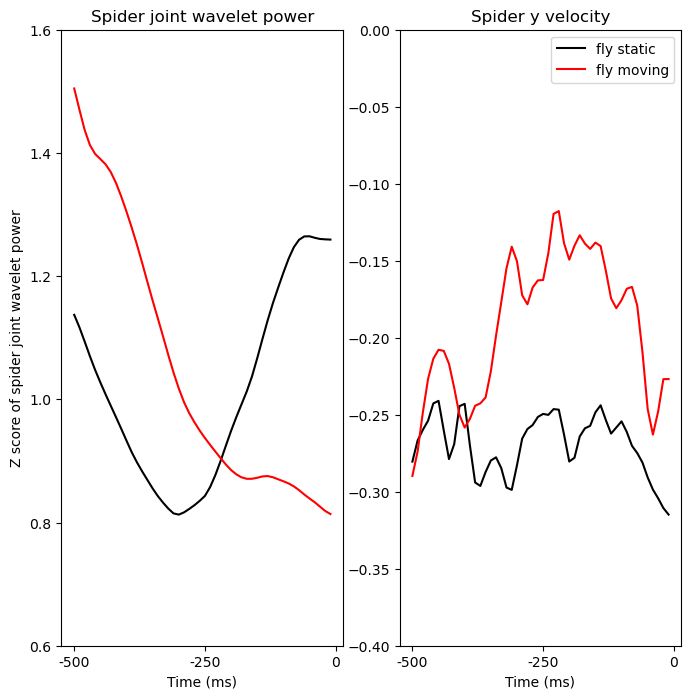

In [46]:
fig, axs = plt.subplots(1,2, figsize=(8, 8))
axs[0].plot(sta_all[0], color='black')
axs[0].plot(sta_all[1], color='red')
axs[0].set_xticks([0, 25, 50], [-500, -250, 0])
axs[1].plot(sta_all_x[0], color='black', label='fly static')
axs[1].plot(sta_all_x[1], color='red', label='fly moving')
axs[1].set_xticks([0, 25, 50], [-500, -250, 0])
axs[0].set_xlabel('Time (ms)')
axs[1].set_xlabel('Time (ms)')
axs[0].set_title('Spider joint wavelet power')
axs[1].set_title('Spider y velocity')
axs[0].set_ylim([0.6, 1.6])
axs[1].set_ylim([-0.4, 0])
axs[0].set_ylabel('Z score of spider joint wavelet power')
axs[1].legend()
plt.savefig('fly_glm_filter.svg')
plt.show()

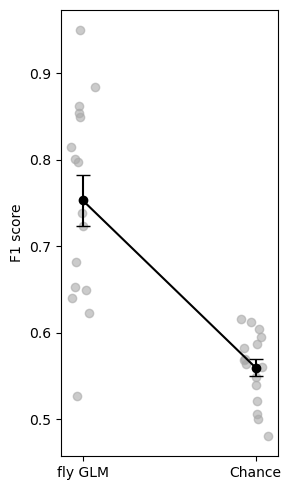

In [47]:
import numpy as np
import matplotlib.pyplot as plt


# Combine into one array
data = [f1_glm, f1_chance]
labels = ['GLM','Chance']



# Scatter plot
plt.figure(figsize=(3, 5))

for i, ll in enumerate(data):
    
    x = np.random.normal(i + 0, 0.05, size=len(ll))  # jitter for visibility
    plt.scatter(x, ll, alpha=0.6, label=labels[i], c='darkgray')
    
    # mean = np.mean(ll)
    # std = np.std(ll)
    # plt.errorbar(i + 2, mean, yerr=std, fmt='o', color='black', capsize=5)

data = np.array(data)
data = np.transpose(data)
mean_bic = np.mean(data, axis=0)
sem_bic = np.std(data, axis=0, ddof=1)/np.sqrt(len(data))
states = np.arange(0, 0 + len(mean_bic))
plt.errorbar(states, mean_bic, yerr=sem_bic, fmt='-o',  color='black', capsize=5 )



# Customize axes
plt.xticks([0,1], ('fly GLM','Chance'))
plt.ylabel('F1 score')

plt.tight_layout()

plt.savefig('flyGLM_compare.svg')
plt.show()

In [48]:
import numpy as np
import pandas as pd
from scipy.stats import shapiro, levene, f_oneway, kruskal, rankdata, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.multicomp import pairwise_tukeyhsd


group1 =  f1_glm
group2 = f1_chance
groups = [group1, group2]

# Normality check
for i, g in enumerate(groups, start=1):
    stat, p = shapiro(g)


# Equal variance check
stat, p_var = levene(*groups)
print(f"Levene's test p={p_var:.4f}")

all_normal = all(shapiro(g)[1] > 0.05 for g in groups)
equal_var = p_var > 0.05

if all_normal and equal_var:
    # One-way ANOVA
    stat, p = f_oneway(*groups)
    print(f"\nOne-way ANOVA: p={p:.4f}")
    
    # Tukey's HSD
    data = np.concatenate(groups)
    labels = np.array(['G1']*len(group1) + ['G2']*len(group2)
                     )
    tukey = pairwise_tukeyhsd(data, labels, alpha=0.05)
    print(tukey)

else:
    # Kruskal–Wallis
    stat, p = kruskal(*groups)
    print(f"\nKruskal–Wallis: p={p:.4f}")
    
    # Manual Dunn's test via pairwise Mann–Whitney + Bonferroni
    labels = ['G1','G2']
    pvals = []
    comparisons = []
    for i in range(len(groups)):
        for j in range(i+1, len(groups)):
            u_stat, p_val = mannwhitneyu(groups[i], groups[j], alternative='two-sided')
            pvals.append(p_val)
            comparisons.append(f"{labels[i]} vs {labels[j]}")
    
    # Multiple testing correction
    reject, pvals_corrected, _, _ = multipletests(pvals, method='bonferroni')
    
    print("\nPost-hoc pairwise tests (Bonferroni corrected):")
    for comp, raw_p, adj_p, rej in zip(comparisons, pvals, pvals_corrected, reject):
        print(f"{comp}: raw p={raw_p:.4f}, adj p={adj_p:.4f}, significant={rej}")


Levene's test p=0.0002

Kruskal–Wallis: p=0.0000

Post-hoc pairwise tests (Bonferroni corrected):
G1 vs G2: raw p=0.0000, adj p=0.0000, significant=True


In [49]:
file_path = 'B:\HsinYi\GitHub\sensory_beh/fly_kmeanlabels.pkl'
with open(file_path, 'rb') as f:
    fly_kmeanlabels = pickle.load(f)

C:\Users\Gordus_Lab\anaconda3\lib\site-packages\scipy\stats\_distn_infrastructure.py:2343: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
C:\Users\Gordus_Lab\anaconda3\lib\site-packages\scipy\stats\_distn_infrastructure.py:2344: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


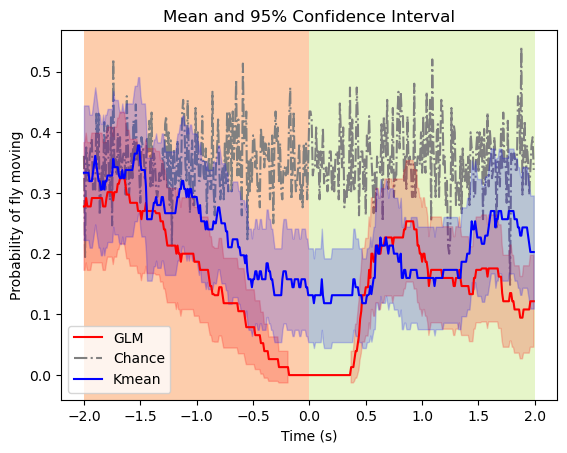

In [50]:
## State transition

extract_glmfly_move = []
extract_fly_kmean = []
extract_chance = []
for i in range(len(spider_labeled_beh)):
    beh = spider_labeled_beh[i]
    linear_fly = fly_kmeanlabels[i]
    glm_fly = glm_fly_beh[i]
    chance = glm_fly_beh_chance[i]


    # Grouping behavior states into blocks
    grouped = [sum(1 for _ in g) for k, g in groupby(beh)]
    labels = [k for k, g in groupby(beh)]
    cumsum = np.cumsum(grouped)
    state1 = 2
    state2 = 1
    start_idx = 0
    for j in range(1, len(cumsum)):
        if labels[j - 1] == state1 and labels[j] == state2:
            idx1 = start_idx
            idx2 = cumsum[j]
            segment_beh = beh[idx1:idx2]

            # Get the first index of state 0 within this chunk
            try:
                state_2_start = np.where(np.array(segment_beh) == state2)[0][0]
            except IndexError:
                continue  # skip if no state 0 found (shouldn't happen but just in case)

            anchor = idx1 + state_2_start  # absolute index in original sequence

            # Create NaN-filled segments for both spider and fly
            seg_fly = np.full((400,), np.nan)
            seg_fly_glm = np.full((400,), np.nan)
            seg_chance = np.full((400,), np.nan)

            win_start = anchor - 200
            win_end = anchor +200

            valid_start = max(win_start, 0)
            valid_end = min(win_end, len(beh))

            seg_start = valid_start - win_start
            seg_end = seg_start + (valid_end - valid_start)

            seg_fly[seg_start:seg_end] = linear_fly[valid_start:valid_end]
            seg_fly_glm[seg_start:seg_end] = glm_fly[valid_start:valid_end]
            seg_chance[seg_start:seg_end] = chance[valid_start:valid_end]
            extract_fly_kmean.append(seg_fly)
            extract_glmfly_move.append(seg_fly_glm)
            extract_chance.append(seg_chance)

        start_idx = cumsum[j - 1]

trans_output = np.array(extract_fly_kmean)
trans_output_glm = np.array(extract_glmfly_move)
trans_output_chance = np.array(extract_chance)


### Plot state transition

import matplotlib.pyplot as plt
from matplotlib.pyplot import get_cmap
from scipy import stats

rainbow = get_cmap('Pastel2', 256)
newcolors = rainbow(np.linspace(0, 1, 8))
newcolors= np.delete(newcolors, 0, 0)
newcolors= np.delete(newcolors, 2, 0)
newcolors= np.delete(newcolors, [3,4,5], 0)
newcolors = np.roll(newcolors, -1, 0)
tab10 = get_cmap('tab10', 256)
ntabl10 = tab10(np.linspace(0, 1,10))

array = np.array(trans_output_glm)
# Calculate the mean while ignoring NaNs
mean = np.nanmean(array, axis=0)
# Calculate the standard error of the mean while ignoring NaNs
n = np.sum(~np.isnan(array), axis=0)  # Number of non-NaN elements along the axis
stderr = np.nanstd(array, axis=0) / np.sqrt(n)
# Calculate the 95% confidence interval
confidence_level = 0.95
degrees_freedom = n - 1
confidence_interval = stats.t.interval(confidence_level, degrees_freedom, loc=mean, scale=stderr)
# Separate the lower and upper bounds of the confidence interval
ci_lower, ci_upper = confidence_interval
# Plotting
x = np.arange(-2,2, 0.01)  # Create an array of x values corresponding to the number of columns
fig, ax1 = plt.subplots()
# Plot the mean values
lns1=ax1.plot(x, mean, label='GLM', color='red')
# Plot the confidence intervals
ax1.fill_between(x, ci_lower, ci_upper, color='red', alpha=0.2,  zorder=1)




array = np.array(trans_output_chance)
# Calculate the mean while ignoring NaNs
mean = np.nanmean(array, axis=0)
# Calculate the standard error of the mean while ignoring NaNs
n = np.sum(~np.isnan(array), axis=0)  # Number of non-NaN elements along the axis
stderr = np.nanstd(array, axis=0) / np.sqrt(n)
# Calculate the 95% confidence interval
confidence_level = 0.95
degrees_freedom = n - 1
confidence_interval = stats.t.interval(confidence_level, degrees_freedom, loc=mean, scale=stderr)
# Separate the lower and upper bounds of the confidence interval
ci_lower, ci_upper = confidence_interval
lns3=ax1.plot(x, mean, label='Chance', color='grey',  zorder=-1, linestyle='-.')




array = np.array(trans_output)
# Calculate the mean while ignoring NaNs
mean = np.nanmean(array, axis=0)
# Calculate the standard error of the mean while ignoring NaNs
n = np.sum(~np.isnan(array), axis=0)  # Number of non-NaN elements along the axis
stderr = np.nanstd(array, axis=0) / np.sqrt(n)
# Calculate the 95% confidence interval
confidence_level = 0.95
degrees_freedom = n - 1
confidence_interval = stats.t.interval(confidence_level, degrees_freedom, loc=mean, scale=stderr)
# Separate the lower and upper bounds of the confidence interval
ci_lower, ci_upper = confidence_interval
# Plotting
x = np.arange(-2,2, 0.01)  # Create an array of x values corresponding to the number of columns
# Plot the mean values
lns2=ax1.plot(x, mean, label='Kmean', color='blue')
# Plot the confidence intervals
ax1.fill_between(x, ci_lower, ci_upper, color='blue', alpha=0.2,  zorder=1)


#ax1.fill_between(x, ci_lower, ci_upper, color='grey', alpha=0.2,  zorder=1)
ax1.tick_params(axis='y', labelcolor='black')

# ax1.set_ylim([-0.1,1])

ax1.axvspan(-2, 0, ymin=0, ymax = 1, facecolor=newcolors[state1], alpha=1, zorder=-2)
ax1.axvspan(0, 2, ymin=0, ymax = 1, facecolor=newcolors[state2], alpha=1, zorder=-2)

# Add labels and title
plt.xlabel('Time (s)')
ax1.set_ylabel('Probability of fly moving')
lns = lns1+lns3+lns2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc=0)
plt.title('Mean and 95% Confidence Interval')
# Show the plot
plt.savefig('flyGM_shaketocrouch.svg')
plt.show()


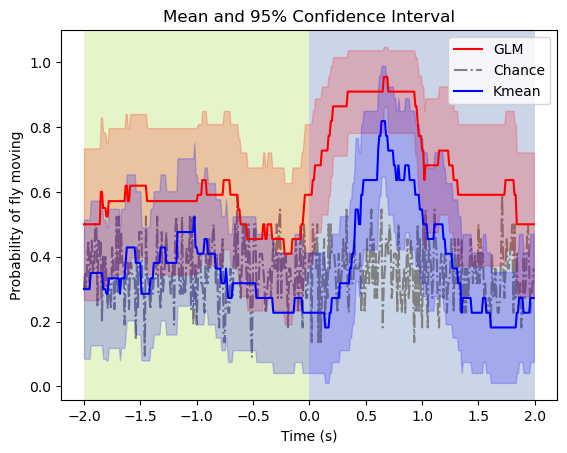

In [51]:
## State transition

## State transition

extract_glmfly_move = []
extract_fly_kmean = []
extract_chance = []
for i in range(len(spider_labeled_beh)):
    beh = spider_labeled_beh[i]
    linear_fly = fly_kmeanlabels[i]
    glm_fly = glm_fly_beh[i]
    chance = glm_fly_beh_chance[i]


    # Grouping behavior states into blocks
    grouped = [sum(1 for _ in g) for k, g in groupby(beh)]
    labels = [k for k, g in groupby(beh)]
    cumsum = np.cumsum(grouped)
    state1 = 1
    state2 = 0
    start_idx = 0
    for j in range(1, len(cumsum)):
        if labels[j - 1] == state1 and labels[j] == state2:
            idx1 = start_idx
            idx2 = cumsum[j]
            segment_beh = beh[idx1:idx2]

            # Get the first index of state 0 within this chunk
            try:
                state_2_start = np.where(np.array(segment_beh) == state2)[0][0]
            except IndexError:
                continue  # skip if no state 0 found (shouldn't happen but just in case)

            anchor = idx1 + state_2_start  # absolute index in original sequence

            # Create NaN-filled segments for both spider and fly
            seg_fly = np.full((400,), np.nan)
            seg_fly_glm = np.full((400,), np.nan)
            seg_chance = np.full((400,), np.nan)

            win_start = anchor - 200
            win_end = anchor +200

            valid_start = max(win_start, 0)
            valid_end = min(win_end, len(beh))

            seg_start = valid_start - win_start
            seg_end = seg_start + (valid_end - valid_start)

            seg_fly[seg_start:seg_end] = linear_fly[valid_start:valid_end]
            seg_fly_glm[seg_start:seg_end] = glm_fly[valid_start:valid_end]
            seg_chance[seg_start:seg_end] = chance[valid_start:valid_end]
            extract_fly_kmean.append(seg_fly)
            extract_glmfly_move.append(seg_fly_glm)
            extract_chance.append(seg_chance)

        start_idx = cumsum[j - 1]

trans_output = np.array(extract_fly_kmean)
trans_output_glm = np.array(extract_glmfly_move)
trans_output_chance = np.array(extract_chance)


### Plot state transition

import matplotlib.pyplot as plt
from matplotlib.pyplot import get_cmap
from scipy import stats

rainbow = get_cmap('Pastel2', 256)
newcolors = rainbow(np.linspace(0, 1, 8))
newcolors= np.delete(newcolors, 0, 0)
newcolors= np.delete(newcolors, 2, 0)
newcolors= np.delete(newcolors, [3,4,5], 0)
newcolors = np.roll(newcolors, -1, 0)
tab10 = get_cmap('tab10', 256)
ntabl10 = tab10(np.linspace(0, 1,10))

array = np.array(trans_output_glm)
# Calculate the mean while ignoring NaNs
mean = np.nanmean(array, axis=0)
# Calculate the standard error of the mean while ignoring NaNs
n = np.sum(~np.isnan(array), axis=0)  # Number of non-NaN elements along the axis
stderr = np.nanstd(array, axis=0) / np.sqrt(n)
# Calculate the 95% confidence interval
confidence_level = 0.95
degrees_freedom = n - 1
confidence_interval = stats.t.interval(confidence_level, degrees_freedom, loc=mean, scale=stderr)
# Separate the lower and upper bounds of the confidence interval
ci_lower, ci_upper = confidence_interval
# Plotting
x = np.arange(-2,2, 0.01)  # Create an array of x values corresponding to the number of columns
fig, ax1 = plt.subplots()
# Plot the mean values
lns1=ax1.plot(x, mean, label='GLM', color='red')
# Plot the confidence intervals
ax1.fill_between(x, ci_lower, ci_upper, color='red', alpha=0.2,  zorder=1)




array = np.array(trans_output_chance)
# Calculate the mean while ignoring NaNs
mean = np.nanmean(array, axis=0)
# Calculate the standard error of the mean while ignoring NaNs
n = np.sum(~np.isnan(array), axis=0)  # Number of non-NaN elements along the axis
stderr = np.nanstd(array, axis=0) / np.sqrt(n)
# Calculate the 95% confidence interval
confidence_level = 0.95
degrees_freedom = n - 1
confidence_interval = stats.t.interval(confidence_level, degrees_freedom, loc=mean, scale=stderr)
# Separate the lower and upper bounds of the confidence interval
ci_lower, ci_upper = confidence_interval
lns3=ax1.plot(x, mean, label='Chance', color='grey',  zorder=-1, linestyle='-.')




array = np.array(trans_output)
# Calculate the mean while ignoring NaNs
mean = np.nanmean(array, axis=0)
# Calculate the standard error of the mean while ignoring NaNs
n = np.sum(~np.isnan(array), axis=0)  # Number of non-NaN elements along the axis
stderr = np.nanstd(array, axis=0) / np.sqrt(n)
# Calculate the 95% confidence interval
confidence_level = 0.95
degrees_freedom = n - 1
confidence_interval = stats.t.interval(confidence_level, degrees_freedom, loc=mean, scale=stderr)
# Separate the lower and upper bounds of the confidence interval
ci_lower, ci_upper = confidence_interval
# Plotting
x = np.arange(-2,2, 0.01)  # Create an array of x values corresponding to the number of columns
# Plot the mean values
lns2=ax1.plot(x, mean, label='Kmean', color='blue')
# Plot the confidence intervals
ax1.fill_between(x, ci_lower, ci_upper, color='blue', alpha=0.2,  zorder=1)


#ax1.fill_between(x, ci_lower, ci_upper, color='grey', alpha=0.2,  zorder=1)
ax1.tick_params(axis='y', labelcolor='black')

# ax1.set_ylim([-0.1,1])

ax1.axvspan(-2, 0, ymin=0, ymax = 1, facecolor=newcolors[state1], alpha=1, zorder=-2)
ax1.axvspan(0, 2, ymin=0, ymax = 1, facecolor=newcolors[state2], alpha=1, zorder=-2)

# Add labels and title
plt.xlabel('Time (s)')
ax1.set_ylabel('Probability of fly moving')
lns = lns1+lns3+lns2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc=0)
plt.title('Mean and 95% Confidence Interval')
# Show the plot

plt.savefig('flyGM_crouchtostatic.svg')
plt.show()


In [52]:
import numpy as np



# Accuracy for state 0
state0_mask = (np.array(labeled_beh_extend) == 0)
acc_0 = np.mean(binary_arr[state0_mask] == 0)

# Accuracy for state 1
state1_mask = (np.array(labeled_beh_extend) == 1)
acc_1 = np.mean(binary_arr[state1_mask] == 1)

print("State 0 accuracy:", acc_0)
print("State 1 accuracy:", acc_1)


State 0 accuracy: 0.7936368623148656
State 1 accuracy: 0.6473410635745702


In [53]:
import glob
import matplotlib
from sklearn import linear_model
from scipy.signal import hilbert
from scipy import signal
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score

import pickle

def calculate_log_likelihood(y_true, y_pred_proba):
    """
    Calculates the log-likelihood for logistic regression.

    Args:
        y_true (array-like): True labels (0 or 1).
        y_pred_proba (array-like): Predicted probabilities of the positive class.

    Returns:
        float: The log-likelihood value.
    """
    # Ensure probabilities are not exactly 0 or 1 to avoid log(0) issues
    y_pred_proba = np.clip(y_pred_proba, 1e-10, 1 - 1e-10)

    log_likelihood = np.sum(y_true * np.log(y_pred_proba) + (1 - y_true) * np.log(1 - y_pred_proba))
    return log_likelihood

file_path = 'B:\HsinYi\GitHub\sensory_beh/fly_kmeanlabels.pkl'
with open(file_path, 'rb') as f:
    fly_kmeanlabels = pickle.load(f)

roll_time = 5  #rolling time for probility estimation of the outcome
states_label=[0,1]
v_smooth_window=2
lp_f = 25
accuracy_list=[]
accuracy_list2=[]
accuracy_list4=[]
states_linear_output=[]
states_linear_output2=[]
states_linear_output4=[]
sta_all=[]
sta_vx_all=[]
sta_all_x=[]
sta_all_y=[]



n_features = 1
joint=2
windows=[10, 25, 100]
for stimulus_window in windows:
    window = stimulus_window
    shuffled_indicies = np.random.permutation(42991-(window-10)*16)
    train_data_size = int((42991-(window-10)*16) * 3 / 4)
    print(stimulus_window)
    prob_states_mul_lr=[]
    prob_states_lr = []
    prob_states_lr_2 = []
    prob_states_lr_4=[]


    for states in states_label:
        #initial_time = [569, 276, 99,184,1776,567,2435,226,1017]
        initial_time = [569, 276, 99,1776,  567, 2435,  141, 109, 204, 400, 377, 206, 170,177, 207, 169]

        videodirectory = 'B:/HsinYi/GitHub/sensory_beh/'
        videoname = '*'
        sensory_dic = videodirectory+'sensory_auto/'
        sensory_roi_files = glob.glob(sensory_dic+ videoname+ '_roi_coordinates_side.npz')
        sensory_stft_files = glob.glob(sensory_dic+ videoname+ '_roi_stft_side.npz')

        spider_labeled_beh = []
        fly_kmeanlabel_beh=[]
        observations = []
        stimulus =[]
        stimulus_all=[]
        stimulus_y = []
        stimulus_r=[]
        stimulus_all_r=[]
        stimulus_all_y = []
        stimulus_v_x = []
        stimulus_v_y = []
        stimulus_v_x_all = []
        stimulus_v_y_all = []

        observations_fly = []
        for j in range(len(sensory_roi_files)):
            sensory_roi = np.load(sensory_roi_files[j])
            roi_fly_list = sensory_roi['roi_fly_list']
            roi_spider_list = sensory_roi['roi_spider_list']
            nframes = roi_fly_list.shape[0]
            vid_name = sensory_roi_files[j].split('/sensory_auto\\')[1].split('_roi_coordinates_side.npz')[0]
            x = roi_spider_list[:, 0] + roi_spider_list[:, 2] / 2
            v_x = x - np.roll(x, 1)
            v_x = v_x[1:len(v_x)]
            y = roi_spider_list[:, 1] + roi_spider_list[:, 3] / 2
            v_y = y - np.roll(y, 1)
            v_y = v_y[1:len(v_y)]
            v_x = hilbert(v_x)
            v_x = np.abs(v_x)
            v_y = hilbert(v_y)
            v_y = np.abs(v_y)
            r = roi_spider_list[:, 1] + roi_spider_list[:, 3] / 2 - roi_fly_list[:, 1] - roi_fly_list[:, 3] / 2
            r = np.abs(r)
            r = r / ((roi_spider_list[:, 2] + roi_spider_list[:, 3])) / 2
            # r = r / np.min(r)
            r = (1 / r) ** 2
            r = r / np.max(r)
            r[np.where(r < 0.5)[0]] = 0.5

            vid_name = sensory_roi_files[j].split('/sensory_auto\\')[1].split('_roi_coordinates_side.npz')[0]

            ## Spider's beh
            beh_hmm = np.load(
                glob.glob(videodirectory + 'sensory_auto/' + vid_name + '*_hmm_umap_filtered_predictedlabels.npy')[0]
                )

            wavelet =  np.load(
                glob.glob(videodirectory + 'sensory_auto/' + vid_name + '*_nonormalized_wavelet.npz')[0]
                )
            wavelet_x = wavelet['arr_0']
            wavelet_y = wavelet['arr_1']
            ff = wavelet['arr_2']
            ## Sensory
            wavelet_x = wavelet_x[0:len(beh_hmm), :]  ## ignore wrapping time
            wavelet_x = wavelet_x.reshape(wavelet_x.shape[0], 5, 50)
            wavelet_x = np.mean(wavelet_x[:, :, 25:46], axis=1)
            wavelet_x = wavelet_x.reshape(wavelet_x.shape[0], 21)
            wavelet_x = np.mean(wavelet_x, axis=1)

            # wavelet_y = wavelet_y[0:len(beh_hmm), :]  ## ignore wrapping time
            # wavelet_y = wavelet_y.reshape(wavelet_x.shape[0], 5, 50)
            # wavelet_y = wavelet_y[:, joint, 25:46]
            # wavelet_y = wavelet_y.reshape(wavelet_y.shape[0], 21)
            # wavelet_y = np.mean(wavelet_y, axis=1)
            # wavelet_y = beh_hmm

            #wavelet_x = (wavelet_x - np.mean(wavelet_x)) / np.std(wavelet_x)




            t3 = [i for i in range(0, initial_time[j], 1)]
            t3 = np.array(t3)
            yinterp3 =wavelet_x[0:initial_time[j]]
            yinterp3_mean = np.mean(yinterp3)
            yinterp3_std = np.std(yinterp3)
            # yinterp3_y = wavelet_y[0:initial_time[j]]
            # yinterp3_mean_y = np.mean(yinterp3_y)
            # yinterp3_std_y = np.std(yinterp3_y)

            t2 = [i for i in range(initial_time[j], (len(beh_hmm) + initial_time[j]), 1)]
            # # t= [i for i in range(4000, 6000, 10)]
            t2 = np.array(t2)
            #
            yinterp = np.copy(wavelet_x)
            yinterp = (yinterp - yinterp3_mean) / yinterp3_std
            # yinterp_y = np.copy(wavelet_y)
            # yinterp_y = (yinterp_y - yinterp3_mean_y) / yinterp3_std_y

            yinterp_y = np.copy(beh_hmm)
            r = r[t2][0:len(r[t2])]
            sos = signal.butter(10, lp_f, 'lp', fs=100, output='sos')
            r = signal.sosfilt(sos, r)
            r = (r - np.mean(r)) / np.std(r)
            v_x_sensory = v_x[t2][0:len(v_x[t2])]
            v_y_sensory = v_y[t2][0:len(v_y[t2])]

            sos = signal.butter(10, lp_f, 'lp', fs=100, output='sos')
            v_x_sensory = signal.sosfilt(sos, v_x_sensory)
            v_y_sensory = signal.sosfilt(sos, v_y_sensory)

            v_x_sensory = (v_x_sensory - np.mean(v_x_sensory)) / np.std(v_x_sensory)
            v_y_sensory = (v_y_sensory - np.mean(v_y_sensory)) / np.std(v_y_sensory)

            ## Spike trigger average
            from itertools import groupby
            count_dups = [sum(1 for _ in group) for _, group in groupby(fly_kmeanlabels[j])]
            cumsum = np.cumsum(count_dups)

            groups = []
            uniquekeys = []
            for k, g in groupby(fly_kmeanlabels[j]):
                groups.append(list(g))  # Store group iterator as a list
                uniquekeys.append(k)

            idx = np.where(np.array(uniquekeys)==states)
            stimulus_temp=[]
            stimulus_temp_y=[]
            stimulus_r_temp = []
            stimulus_v_x_temp = []
            stimulus_v_y_temp = []


            for trigger in range(len(idx[0])):
                if idx[0][trigger]==0:
                    continue
                else:
                    event_time = cumsum[idx[0][trigger]-1]
                    if len(yinterp[event_time - stimulus_window:event_time])==0:
                        stimulus.append(yinterp[0:stimulus_window])
                        stimulus_temp.append(yinterp[0:stimulus_window])
                        stimulus_y.append(yinterp_y[0:stimulus_window])
                        stimulus_temp_y.append(yinterp_y[0:stimulus_window])
                        stimulus_r.append(r[0:stimulus_window])
                        stimulus_r_temp.append(r[0:stimulus_window])
                        stimulus_v_x.append(v_x_sensory[0:stimulus_window])
                        stimulus_v_y.append(v_y_sensory[0:stimulus_window])
                        stimulus_v_x_temp.append(v_x_sensory[0:stimulus_window])
                        stimulus_v_y_temp.append(v_y_sensory[0:stimulus_window])

                    else:
                        stimulus.append(yinterp[event_time - stimulus_window:event_time])
                        stimulus_temp.append(yinterp[event_time - stimulus_window:event_time])
                        stimulus_y.append(yinterp_y[event_time - stimulus_window:event_time])
                        stimulus_temp_y.append(yinterp_y[event_time - stimulus_window:event_time])
                        stimulus_r.append(r[event_time - stimulus_window:event_time])
                        stimulus_r_temp.append(r[event_time - stimulus_window:event_time])
                        stimulus_v_x.append(v_x_sensory[event_time - stimulus_window:event_time])
                        stimulus_v_y.append(v_y_sensory[event_time - stimulus_window:event_time])
                        stimulus_v_x_temp.append(v_x_sensory[event_time - stimulus_window:event_time])
                        stimulus_v_y_temp.append(v_y_sensory[event_time - stimulus_window:event_time])

            stimulus_all.append(stimulus_temp)
            stimulus_all_y.append(stimulus_temp_y)
            stimulus_all_r.append(stimulus_r_temp)
            stimulus_v_x_all.append(stimulus_v_x_temp)
            stimulus_v_y_all.append(stimulus_v_y_temp)


            fly_kmeanlabel_beh.append(fly_kmeanlabels[j])
            spider_labeled_beh.append(beh_hmm[stimulus_window:len(beh_hmm)])
            observations.append(list(yinterp))



        ## Spike trigger average of all videos. Mean centered
        stimulus_test = np.array(stimulus)
        data_ensembles_len = stimulus_test.shape[0]
        arr = np.arange(data_ensembles_len)
        np.random.shuffle(arr)
        #train_set = stimulus_test[arr[0:int(len(arr)*3/4)]]
        #test_set = stimulus_test[arr[int(len(arr)*3/4):len(arr)]]
        train_set = stimulus_test
        sta = np.mean(train_set, axis=0)
 
        sta_all.append(sta)


        stimulus_test = np.array(stimulus_v_x)
        data_ensembles_len = stimulus_test.shape[0]
        arr = np.arange(data_ensembles_len)
        np.random.shuffle(arr)
        # train_set = stimulus_test[arr[0:int(len(arr)*3/4)]]
        # test_set = stimulus_test[arr[int(len(arr)*3/4):len(arr)]]
        train_set = stimulus_test
        sta_x = np.mean(train_set, axis=0)
 
        sta_all_x.append(sta_x)


        stimulus_test = np.array(stimulus_v_y)
        data_ensembles_len = stimulus_test.shape[0]
        arr = np.arange(data_ensembles_len)
        np.random.shuffle(arr)
        # train_set = stimulus_test[arr[0:int(len(arr)*3/4)]]
        # test_set = stimulus_test[arr[int(len(arr)*3/4):len(arr)]]
        train_set = stimulus_test
        sta_y = np.mean(train_set, axis=0)

        sta_all_y.append(sta_y)




        ### Step 2: Linear Output

        labeled_beh = []
        observations = []
        observations_fly = []

        linear_output_all=[]
        linear_output_all_y=[]
        linear_output_all_x=[]

        for j in range(len(sensory_roi_files)):
            sensory_roi = np.load(sensory_roi_files[j])
            roi_fly_list = sensory_roi['roi_fly_list']
            roi_spider_list = sensory_roi['roi_spider_list']
            nframes = roi_fly_list.shape[0]
            vid_name = sensory_roi_files[j].split('/sensory_auto\\')[1].split('_roi_coordinates_side.npz')[0]
            x = roi_spider_list[:, 0] + roi_spider_list[:, 2] / 2
            v_x = x - np.roll(x, 1)
            v_x = v_x[1:len(v_x)]
            y = roi_spider_list[:, 1] + roi_spider_list[:, 3] / 2
            v_y = y - np.roll(y, 1)
            v_y = v_y[1:len(v_y)]
            v_x = hilbert(v_x)
            v_x = np.abs(v_x)
            v_y = hilbert(v_y)
            v_y = np.abs(v_y)
            sensory_roi = np.load(sensory_roi_files[j])
            roi_fly_list = sensory_roi['roi_fly_list']
            roi_spider_list = sensory_roi['roi_spider_list']
            nframes = roi_fly_list.shape[0]
            vid_name = sensory_roi_files[j].split('/sensory_auto\\')[1].split('_roi_coordinates_side.npz')[0]
            r = roi_spider_list[:, 1] + roi_spider_list[:, 3] / 2 - roi_fly_list[:, 1] - roi_fly_list[:, 3] / 2
            r = np.abs(r)
            r = r / ((roi_spider_list[:, 2] + roi_spider_list[:, 3])) / 2
            # r = r / np.min(r)
            r = (1 / r) ** 2
            r = r / np.max(r)
            r[np.where(r < 0.5)[0]] = 0.5

            vid_name = sensory_roi_files[j].split('/sensory_auto\\')[1].split('_roi_coordinates_side.npz')[0]

            ## Spider's beh
            beh_hmm = np.load(
                glob.glob(videodirectory + 'sensory_auto/' + vid_name + '*_hmm_umap_filtered_predictedlabels.npy')[0]
            )

            wavelet = np.load(
                glob.glob(videodirectory + 'sensory_auto/' + vid_name + '*_nonormalized_wavelet.npz')[0]
            )
            wavelet_x = wavelet['arr_0']
            wavelet_y = wavelet['arr_1']
            ff = wavelet['arr_2']
            ## Sensory
            wavelet_x = wavelet_x[0:len(beh_hmm), :]  ## ignore wrapping time
            wavelet_x = wavelet_x.reshape(wavelet_x.shape[0], 5, 50)
            wavelet_x = np.mean(wavelet_x[:, :, 25:46], axis=1)
            wavelet_x = wavelet_x.reshape(wavelet_x.shape[0], 21)
            wavelet_x = np.mean(wavelet_x, axis=1)


            yinterp3 = wavelet_x[0:initial_time[j]]
            yinterp3_mean = np.mean(yinterp3)
            yinterp3_std = np.std(yinterp3)
            # yinterp3_y = wavelet_y[0:initial_time[j]]
            # yinterp3_mean_y = np.mean(yinterp3_y)
            # yinterp3_std_y = np.std(yinterp3_y)

            t2 = [i for i in range(initial_time[j], (len(beh_hmm) + initial_time[j]), 1)]
            # # t= [i for i in range(4000, 6000, 10)]
            t2 = np.array(t2)
            #
            yinterp = np.copy(wavelet_x)
            yinterp = (yinterp - yinterp3_mean) / yinterp3_std
            # yinterp_y = np.copy(wavelet_y)
            # yinterp_y = (yinterp_y - yinterp3_mean_y) / yinterp3_std_y

            yinterp_y = np.copy(beh_hmm)

            r = r[t2][0:len(r[t2])]
            sos = signal.butter(10, lp_f, 'lp', fs=100, output='sos')
            r = signal.sosfilt(sos, r)
            r = (r - np.mean(r)) / np.std(r)
            v_x_sensory = v_x[t2][0:len(v_x[t2])]
            v_y_sensory = v_y[t2][0:len(v_y[t2])]

            sos = signal.butter(10, lp_f, 'lp', fs=100, output='sos')
            v_x_sensory = signal.sosfilt(sos, v_x_sensory)
            v_y_sensory = signal.sosfilt(sos, v_y_sensory)

            v_x_sensory = (v_x_sensory - np.mean(v_x_sensory)) / np.std(v_x_sensory)
            v_y_sensory = (v_y_sensory - np.mean(v_y_sensory)) / np.std(v_y_sensory)


            X_windows = np.array([yinterp[t - window:t] for t in range(window, yinterp.shape[0])])
            X_flat = X_windows.reshape((yinterp.shape[0] - window, window * n_features))
            linear_output = X_flat @ sta.reshape(-1)

            Y_windows = np.array([v_x_sensory [t - window:t] for t in range(window, v_x_sensory .shape[0])])
            Y_flat = Y_windows.reshape((v_x_sensory .shape[0] - window, window * n_features))
            linear_output_x = Y_flat @ sta_x.reshape(-1)

            Y_windows = np.array([v_y_sensory[t - window:t] for t in range(window, v_y_sensory.shape[0])])
            Y_flat = Y_windows.reshape((v_y_sensory.shape[0] - window, window * n_features))
            linear_output_y = Y_flat @ sta_y.reshape(-1)

            linear_output = np.array(linear_output)
            linear_output = (linear_output - np.min(linear_output)) / (np.max(linear_output) - np.min(linear_output))
            linear_output_all.append(linear_output)

            linear_output_x = np.array(linear_output_x)
            linear_output_x = (linear_output_x - np.min(linear_output_x)) / (np.max(linear_output_x) - np.min(linear_output_x))
            linear_output_all_x.append(linear_output_x)
            linear_output_y = np.array(linear_output_y)
            linear_output_y = (linear_output_y - np.min(linear_output_y)) / (
                        np.max(linear_output_y) - np.min(linear_output_y))
            linear_output_all_y.append(linear_output_y)

            labeled_beh.append(fly_kmeanlabels[j][window-10:len(fly_kmeanlabels[j])])

        linear_output_extend=[]
        linear_output_extend_y = []
        linear_output_extend_x = []
        linear_output_fly_extend = []
        spider_labeled_beh_extend=[]
        labeled_beh_extend=[]
        for i in range(len(linear_output_all)):
            linear_output_extend.extend(linear_output_all[i])
            linear_output_extend_y.extend(linear_output_all_y[i])
            linear_output_extend_x.extend(linear_output_all_x[i])
            spider_labeled_beh_extend.extend(spider_labeled_beh[i])
            labeled_beh_extend.extend(labeled_beh[i])

        linear_output_sort = np.sort(linear_output_extend)
        ### Step 3: Characterize nonlinearity
        # for i in range(len(linear_output_extend)):
        states_linear_output.append(np.array(linear_output_extend))


        train_x = np.array(linear_output_extend)[shuffled_indicies[:train_data_size]]
        train_y = np.array(labeled_beh_extend)[shuffled_indicies[:train_data_size]]
        test_x = np.array(linear_output_extend)
        test_y = np.array(labeled_beh_extend)

        ##Train multi-classification model with logistic regression

        lr = linear_model.LogisticRegression()
        lr.fit(np.array(train_x).reshape(-1, 1), train_y)
        test_x_prob_lr = lr.predict_proba(np.array(test_x).reshape(-1, 1))
        prob_states_lr.append(test_x_prob_lr)

        # Train multinomial logistic regression model
        mul_lr = linear_model.LogisticRegression(multi_class='multinomial', solver='newton-cg').fit(
            np.array(train_x).reshape(-1, 1), train_y)
        test_x_prob_mul_lr = mul_lr.predict_proba(np.array(test_x).reshape(-1, 1))
        prob_states_mul_lr.append(test_x_prob_mul_lr)


        ## 2 features

        train_x = np.array(linear_output_extend)[shuffled_indicies[:train_data_size]]
        train_x_fly = np.array(linear_output_extend_x)[shuffled_indicies[:train_data_size]]
        train_y = np.array(labeled_beh_extend)[shuffled_indicies[:train_data_size]]
        test_x = np.array(linear_output_extend)
        test_x_fly = np.array(linear_output_extend_x)
        # test_x = np.array(observation_extend)[shuffled_indicies[train_data_size:]]
        test_y = np.array(labeled_beh_extend)
        lr = linear_model.LogisticRegression()
        lr.fit(np.append(train_x, train_x_fly, axis=0).reshape(2, len(train_x)).transpose(), train_y)
        mul_lr = linear_model.LogisticRegression(multi_class='multinomial', solver='newton-cg').fit(
            np.append(train_x, train_x_fly, axis=0).reshape(2, len(train_x)).transpose(), train_y)

        test_x_prob_lr = lr.predict_proba(np.append(test_x, test_x_fly, axis=0).reshape(2, len(test_x)).transpose())
        prob_states_lr_2.append(test_x_prob_lr)
        states_linear_output2.append(np.array(np.append(test_x, test_x_fly, axis=0).reshape(2, len(test_x)).transpose()))

        ### 3 features

        train_x = np.array(linear_output_extend)[shuffled_indicies[:train_data_size]]
        train_x_vx = np.array(linear_output_extend_x)[shuffled_indicies[:train_data_size]]
        train_x_vy = np.array(linear_output_extend_y)[shuffled_indicies[:train_data_size]]
        train_y = np.array(labeled_beh_extend)[shuffled_indicies[:train_data_size]]
        test_x = np.array(linear_output_extend)
        test_x_fly = np.array(linear_output_fly_extend)
        test_x_vx = np.array(linear_output_extend_x)
        test_x_vy = np.array(linear_output_extend_y)
        # test_x = np.array(observation_extend)[shuffled_indicies[train_data_size:]]
        test_y = np.array(labeled_beh_extend)
        lr = linear_model.LogisticRegression()
        # temp = [train_x]+[train_x_fly]+[train_x_vx]+[train_x_vy]
        temp = [train_x] + [train_x_vx] + [train_x_vy]
        temp = np.array(temp)
        lr.fit(temp.transpose(), train_y)
        mul_lr = linear_model.LogisticRegression(multi_class='multinomial', solver='newton-cg').fit(
            temp.transpose(), train_y)
        # temp = [test_x] + [test_x_fly] + [test_x_vx] + [test_x_vy]
        temp = [test_x] + [test_x_vx] + [test_x_vy]
        temp = np.array(temp)
        test_x_prob_lr = lr.predict_proba(temp.transpose())
        prob_states_lr_4.append(test_x_prob_lr)
        states_linear_output4.append(np.array(temp.transpose()))

    prob_temp = np.array(prob_states_lr_2)
    prob_temp = np.swapaxes(prob_temp, 0, 1)
    idx_list = []
    prob = []
    for i in range(len(prob_temp)):
        prob.append(np.mean(prob_temp, axis=1)[i, 1])
        idx_list.append(np.where(prob_temp[i, :] == np.max(prob_temp[i, :]))[1][0])
    idx_list = np.array(idx_list)
    prob = np.array(prob)
    binary_arr = (prob >= 0.5).astype(int)
    print('accuracy = ' ,np.mean(np.array(labeled_beh_extend)==binary_arr))
    
    ll = calculate_log_likelihood(np.array(labeled_beh_extend), prob)/len(prob)
    print(f"Log Likelihood: {ll}")



10


B:\TMP\ipykernel_39164\1544547749.py:109: RuntimeWarning: divide by zero encountered in divide
  r = (1 / r) ** 2
B:\TMP\ipykernel_39164\1544547749.py:110: RuntimeWarning: invalid value encountered in divide
  r = r / np.max(r)
B:\TMP\ipykernel_39164\1544547749.py:313: RuntimeWarning: divide by zero encountered in divide
  r = (1 / r) ** 2
B:\TMP\ipykernel_39164\1544547749.py:314: RuntimeWarning: invalid value encountered in divide
  r = r / np.max(r)
B:\TMP\ipykernel_39164\1544547749.py:109: RuntimeWarning: divide by zero encountered in divide
  r = (1 / r) ** 2
B:\TMP\ipykernel_39164\1544547749.py:110: RuntimeWarning: invalid value encountered in divide
  r = r / np.max(r)
B:\TMP\ipykernel_39164\1544547749.py:313: RuntimeWarning: divide by zero encountered in divide
  r = (1 / r) ** 2
B:\TMP\ipykernel_39164\1544547749.py:314: RuntimeWarning: invalid value encountered in divide
  r = r / np.max(r)


accuracy =  0.7372008094717499
Log Likelihood: -0.5323655394801524
25


B:\TMP\ipykernel_39164\1544547749.py:109: RuntimeWarning: divide by zero encountered in divide
  r = (1 / r) ** 2
B:\TMP\ipykernel_39164\1544547749.py:110: RuntimeWarning: invalid value encountered in divide
  r = r / np.max(r)
B:\TMP\ipykernel_39164\1544547749.py:313: RuntimeWarning: divide by zero encountered in divide
  r = (1 / r) ** 2
B:\TMP\ipykernel_39164\1544547749.py:314: RuntimeWarning: invalid value encountered in divide
  r = r / np.max(r)
B:\TMP\ipykernel_39164\1544547749.py:109: RuntimeWarning: divide by zero encountered in divide
  r = (1 / r) ** 2
B:\TMP\ipykernel_39164\1544547749.py:110: RuntimeWarning: invalid value encountered in divide
  r = r / np.max(r)
B:\TMP\ipykernel_39164\1544547749.py:313: RuntimeWarning: divide by zero encountered in divide
  r = (1 / r) ** 2
B:\TMP\ipykernel_39164\1544547749.py:314: RuntimeWarning: invalid value encountered in divide
  r = r / np.max(r)


accuracy =  0.7417838179223878
Log Likelihood: -0.5302234789849057
100


B:\TMP\ipykernel_39164\1544547749.py:109: RuntimeWarning: divide by zero encountered in divide
  r = (1 / r) ** 2
B:\TMP\ipykernel_39164\1544547749.py:110: RuntimeWarning: invalid value encountered in divide
  r = r / np.max(r)
B:\TMP\ipykernel_39164\1544547749.py:313: RuntimeWarning: divide by zero encountered in divide
  r = (1 / r) ** 2
B:\TMP\ipykernel_39164\1544547749.py:314: RuntimeWarning: invalid value encountered in divide
  r = r / np.max(r)
B:\TMP\ipykernel_39164\1544547749.py:109: RuntimeWarning: divide by zero encountered in divide
  r = (1 / r) ** 2
B:\TMP\ipykernel_39164\1544547749.py:110: RuntimeWarning: invalid value encountered in divide
  r = r / np.max(r)
B:\TMP\ipykernel_39164\1544547749.py:313: RuntimeWarning: divide by zero encountered in divide
  r = (1 / r) ** 2
B:\TMP\ipykernel_39164\1544547749.py:314: RuntimeWarning: invalid value encountered in divide
  r = r / np.max(r)


accuracy =  0.7429664749344179
Log Likelihood: -0.5234740440840361


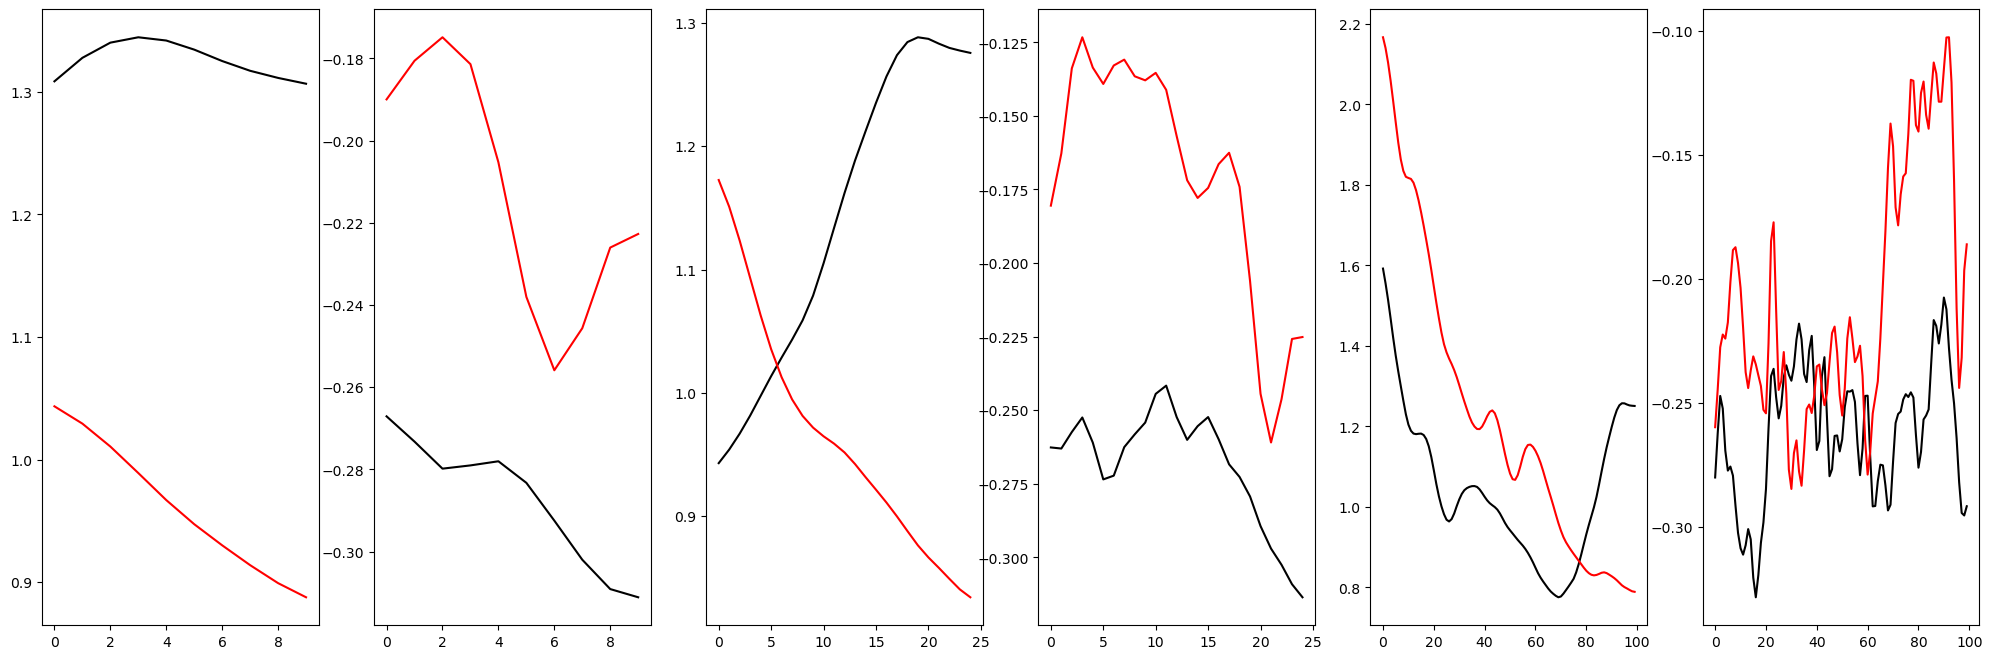

In [54]:
fig, axs = plt.subplots(1,6, figsize=(25,8))
axs[0].plot(sta_all[0], c='black')
axs[0].plot(sta_all[1], c='red')
axs[1].plot(sta_all_x[0], c='black')
axs[1].plot(sta_all_x[1], c='red')
axs[2].plot(sta_all[2], c='black')
axs[2].plot(sta_all[3], c='red')
axs[3].plot(sta_all_x[2], c='black')
axs[3].plot(sta_all_x[3], c='red')
axs[4].plot(sta_all[4], c='black')
axs[4].plot(sta_all[5], c='red')
axs[5].plot(sta_all_x[4], c='black')
axs[5].plot(sta_all_x[5], c='red')
plt.savefig('flyGLM_window.svg')